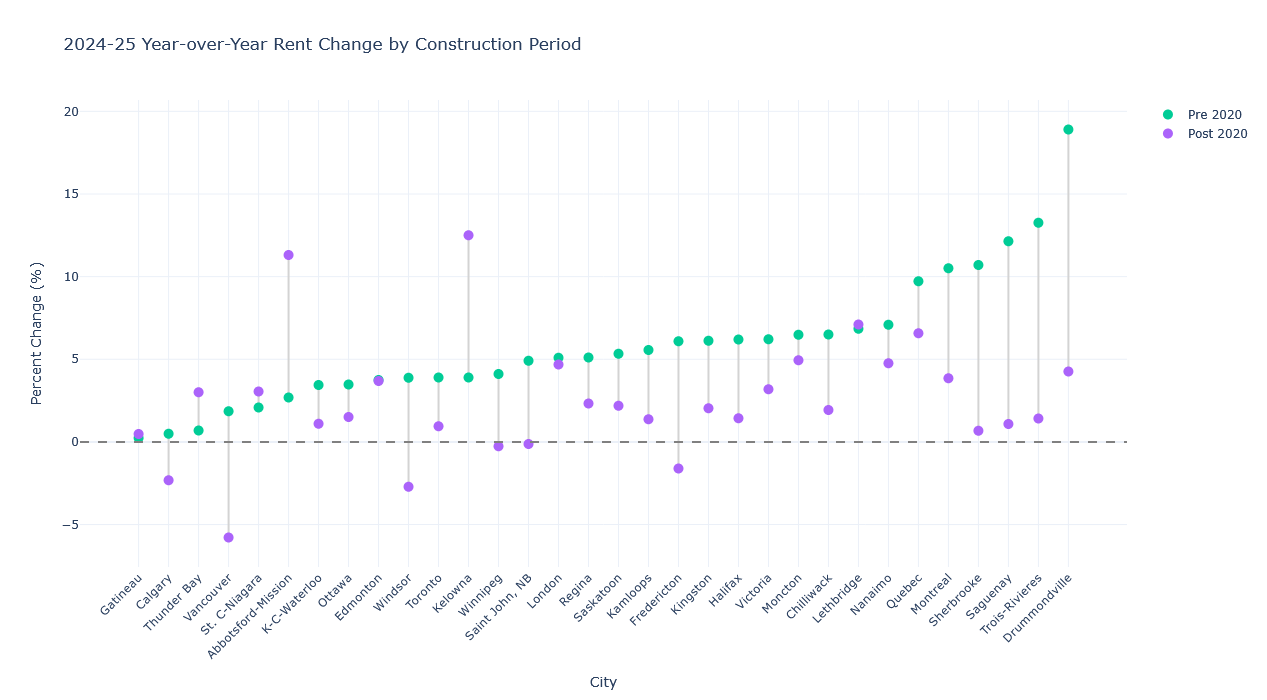

In [4]:
import pandas as pd
import plotly.graph_objects as go

# Load ODS file
df = pd.read_excel(r"Pomeroy Engauge Digitizer point extraction.ods", engine="odf")

# Sort by Pre_2020_Blue to preserve the original chart ordering
df = df.sort_values("Pre_2020_Blue").reset_index(drop=True)

fig = go.Figure()

# Dumbbell connector lines
for _, row in df.iterrows():
    fig.add_trace(
        go.Scatter(
            x=[row["City"], row["City"]],
            y=[row["Pre_2020_Blue"], row["Post_2020_Orange"]],
            mode="lines",
            line=dict(color="lightgray", width=2),
            hoverinfo="skip",
            showlegend=False
        )
    )

# Pre 2020 points
fig.add_trace(
    go.Scatter(
        x=df["City"],
        y=df["Pre_2020_Blue"],
        mode="markers",
        name="Pre 2020 rents",
        marker=dict(size=10)
    )
)

# Post 2020 points
fig.add_trace(
    go.Scatter(
        x=df["City"],
        y=df["Post_2020_Orange"],
        mode="markers",
        name="Post 2020 rents",
        marker=dict(size=10)
    )
)

fig.update_layout(
    title="2024-25 Year-over-Year Rent Change by Construction Period",
    yaxis_title="Percent Change (%)",
    xaxis_title="City",
    height=700,
    width=1400,
    template="plotly_white",
    xaxis=dict(
        tickangle=-45,
        categoryorder="array",
        categoryarray=df["City"]
    )
)

fig.add_hline(y=0, line_dash="dash", line_color="gray")

fig.show()

fig.write_html("pomeroy_dumbbell.html")